In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

fpath = "/content/drive/MyDrive/Human_Development_Index_Dataset (1).csv"
df = pd.read_csv(fpath, encoding='latin1')


In [67]:
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)
unique_years = df['year'].unique()
print("Unique years in dataset:")
print(unique_years)

Unique years in dataset:
[1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022]


In [68]:
hdi_2022_df = df[df['year'] == 2022].copy()
hdi_2022_df.to_csv("hdi_2022_df.csv", index=False)
hdi_2022_df.head(10)

,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,life_expec_m,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,59.766,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,74.502,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,75.853,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,81.430,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,59.351,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,76.507,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,72.851,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,67.866,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,81.708,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,80.150,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


In [69]:
print("Missing values per column:")
print(hdi_2022_df.isnull().sum())


Missing values per column:
iso3                          0
country                       0
year                          0
hdi                           2
life_expectancy               0
pop_millions                  0
hdi_f                        13
hdi_m                        13
life_expec_f                  0
life_expec_m                  0
expec_yr_school               1
expec_yr_school_f             1
expec_yr_school_m             1
mean_yr_school                2
mean_yr_school_f              2
mean_yr_school_m              2
gross_inc_percap              2
gross_inc_percap_f           13
gross_inc_percap_m           13
gender_development           13
gender_inequality            29
secondary_education_f_%      17
secondary_education_m_%      17
seats_in_parliament_f_%       2
seats_in_parliament_m_%       2
labour_participation_f_%     12
labour_participation_m_%     12
co2_emission_tons             2
mat_footprint_percap_tons    41
dtype: int64


In [70]:
numeric_cols = [
    'hdi',
    'life_expectancy',
    'gross_inc_percap',
    'gender_development'
]
for col in numeric_cols:
    hdi_2022_df[col] = pd.to_numeric(hdi_2022_df[col], errors='coerce')


In [71]:
hdi_2022_df.drop_duplicates(inplace=True)


In [72]:
hdi_2022_df.dropna(subset=['hdi'], inplace=True)
print("Missing values after cleaning:")
print(hdi_2022_df.isnull().sum())


Missing values after cleaning:
iso3                          0
country                       0
year                          0
hdi                           0
life_expectancy               0
pop_millions                  0
hdi_f                        11
hdi_m                        11
life_expec_f                  0
life_expec_m                  0
expec_yr_school               0
expec_yr_school_f             0
expec_yr_school_m             0
mean_yr_school                0
mean_yr_school_f              0
mean_yr_school_m              0
gross_inc_percap              0
gross_inc_percap_f           11
gross_inc_percap_m           11
gender_development           11
gender_inequality            27
secondary_education_f_%      15
secondary_education_m_%      15
seats_in_parliament_f_%       2
seats_in_parliament_m_%       2
labour_participation_f_%     11
labour_participation_m_%     11
co2_emission_tons             1
mat_footprint_percap_tons    39
dtype: int64


In [73]:
mean_hdi = hdi_2022_df['hdi'].mean()
median_hdi = hdi_2022_df['hdi'].median()
std_hdi = hdi_2022_df['hdi'].std()

print("Mean HDI:", mean_hdi)
print("Median HDI:", median_hdi)
print("Standard Deviation of HDI:", std_hdi)


Mean HDI: 0.7228872549019609
Median HDI: 0.7395
Standard Deviation of HDI: 0.15302880386427825


In [ ]:
highest_hdi_country = hdi_2022_df.loc[hdi_2022_df['hdi'].idxmax()]
lowest_hdi_country = hdi_2022_df.loc[hdi_2022_df['hdi'].idxmin()]

print("Country with Highest HDI (2022):")
print(highest_hdi_country[['country','hdi']])

print("\nCountry with Lowest HDI (2022):")
print(lowest_hdi_country[['country','hdi']])


Country with Highest HDI (2022):
country    Switzerland
hdi              0.967
Name: 5609, dtype: object

Country with Lowest HDI (2022):
country    Somalia
hdi           0.38
Name: 5345, dtype: object


In [74]:
high_hdi_df = hdi_2022_df[hdi_2022_df['hdi'] > 0.800]
high_hdi_sorted_df = high_hdi_df.sort_values(
    by='gross_inc_percap',
    ascending=False
)
high_hdi_sorted_df[['country','hdi','gross_inc_percap']].head(10)


,country,hdi,gross_inc_percap
3332,Liechtenstein,0.942,146673.24150
4718,Qatar,0.875,95944.37754
5213,Singapore,0.949,88761.14559
2705,Ireland,0.950,87467.51391
3398,Luxembourg,0.927,78554.23640
6104,United Arab Emirates,0.937,74103.71494
5609,Switzerland,0.967,69432.78669
4322,Norway,0.966,69189.76165
6170,United States,0.927,65564.93798
2474,"Hong Kong, China (SAR)",0.956,62485.50516


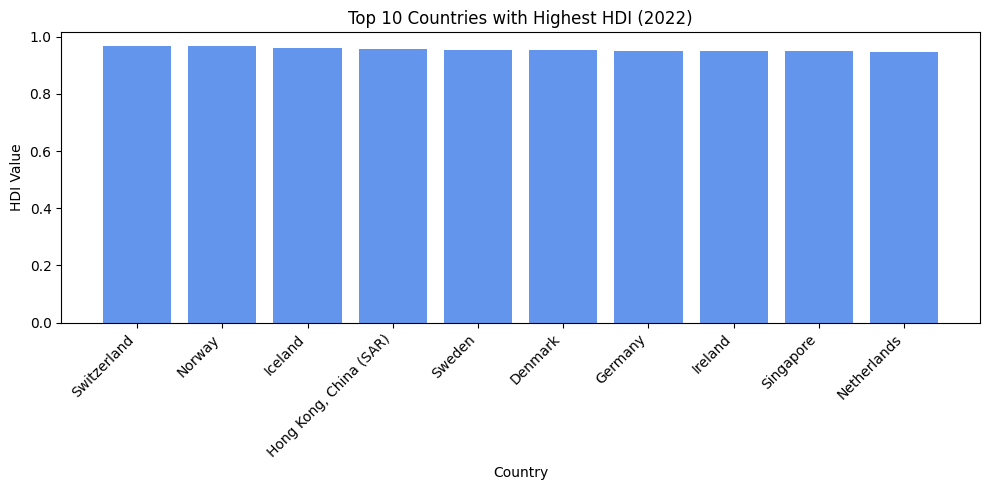

In [75]:
top10_hdi = hdi_2022_df.sort_values(
    by='hdi',
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))
plt.bar(
    top10_hdi['country'],
    top10_hdi['hdi'],
    color='cornflowerblue'
)

plt.xlabel("Country")
plt.ylabel("HDI Value")
plt.title("Top 10 Countries with Highest HDI (2022)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


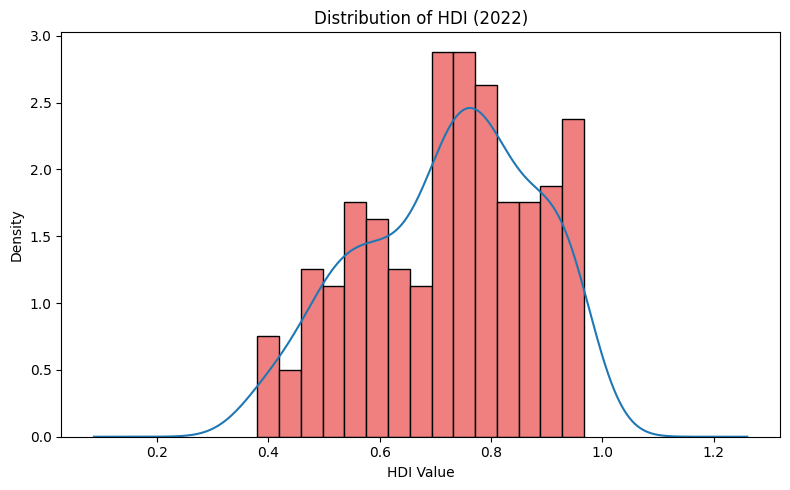

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(hdi_2022_df['hdi'], bins=15, density=True,
         color='lightcoral', edgecolor='black')

hdi_2022_df['hdi'].plot(kind='kde')

plt.xlabel("HDI Value")
plt.ylabel("Density")
plt.title("Distribution of HDI (2022)")
plt.tight_layout()
plt.show()


In [76]:
def hdi_category(hdi):
    if hdi < 0.550:
        return "Low"
    elif hdi < 0.700:
        return "Medium"
    elif hdi < 0.800:
        return "High"
    else:
        return "Very High"
hdi_2022_df['HDI_Category'] = hdi_2022_df['hdi'].apply(hdi_category)
hdi_2022_df['HDI_Category'].value_counts()


,count
HDI_Category,
Very High,71
High,54
Medium,44
Low,35


In [77]:
hdi_2022_df.to_csv("HDI_category_added.csv", index=False)


problem1b

In [78]:
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)
hdi_1b = df[df['year'].isin([2020, 2021, 2022])].copy()
hdi_1b.to_csv("HDI_problem1B.csv", index=False)

hdi_1b.head()

,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,life_expec_m,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
30,AFG,Afghanistan,2020,0.488,62.575,38.972231,0.381373,0.548741,65.432,59.866,...,0.695,0.674,6.092345,15.945160,27.215190,72.784810,16.50,66.84,0.305040,1.5554
31,AFG,Afghanistan,2021,0.473,61.982,40.099462,0.379129,0.528559,65.279,58.915,...,0.717,0.653,6.395730,14.865710,27.215190,72.784810,23.33,77.09,0.306318,1.2351
32,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,59.766,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
63,ALB,Albania,2020,0.784,76.989,2.866849,0.775404,0.793220,79.676,74.632,...,0.978,0.129,82.249185,86.476634,29.508197,70.491803,54.45,68.91,1.750668,10.4704
64,ALB,Albania,2021,0.785,76.463,2.854710,0.777866,0.792942,79.173,74.087,...,0.981,0.117,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.5865


In [81]:
print("Missing values in essential columns:")
print(hdi_1b[['hdi','country','year']].isnull().sum())


Missing values in essential columns:
hdi        8
country    0
year       0
dtype: int64


In [ ]:
numeric_cols = ['hdi','life_expectancy','gross_inc_percap','gender_development']

for col in numeric_cols:
    hdi_1b[col] = pd.to_numeric(hdi_1b[col], errors='coerce')


In [80]:
hdi_1b.drop_duplicates(inplace=True)


In [82]:
hdi_1b.dropna(subset=['hdi','country','year'], inplace=True)
print("Missing values after cleaning:")
print(hdi_1b[['hdi','country','year']].isnull().sum())


Missing values after cleaning:
hdi        0
country    0
year       0
dtype: int64


In [83]:
hdi_1b['country'] = hdi_1b['country'].str.strip()


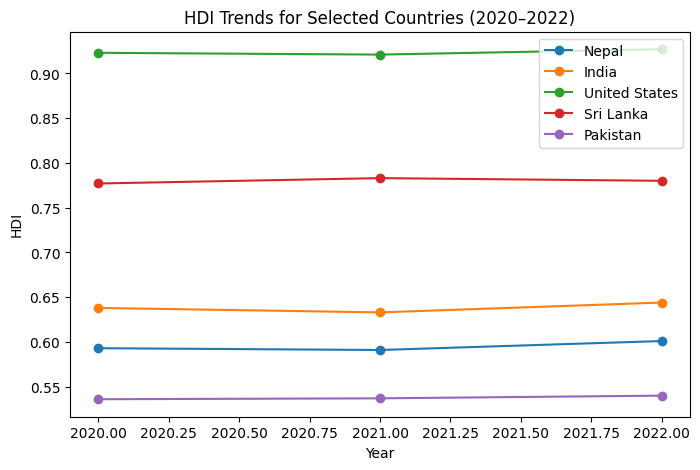

In [84]:
countries = ['Nepal','India','United States','Sri Lanka','Pakistan']

plt.figure(figsize=(8,5))
for c in countries:
    data = hdi_1b[hdi_1b['country'] == c]
    plt.plot(data['year'], data['hdi'], marker='o', label=c)

plt.xlabel("Year")
plt.ylabel("HDI")
plt.title("HDI Trends for Selected Countries (2020–2022)")
plt.legend()
plt.show()


In [85]:
region_map = {
    "Afghanistan":"South Asia","Bangladesh":"South Asia","Bhutan":"South Asia",
    "India":"South Asia","Maldives":"South Asia","Nepal":"South Asia",
    "Pakistan":"South Asia","Sri Lanka":"South Asia",

    "Bahrain":"Middle East","Iran":"Middle East","Iraq":"Middle East",
    "Israel":"Middle East","Jordan":"Middle East","Kuwait":"Middle East",
    "Lebanon":"Middle East","Oman":"Middle East","Palestine":"Middle East",
    "Qatar":"Middle East","Saudi Arabia":"Middle East","Syria":"Middle East",
    "United Arab Emirates":"Middle East","Yemen":"Middle East"
}

hdi_1b['region'] = hdi_1b['country'].map(region_map)
hdi_1b['region'] = hdi_1b['region'].fillna("Other")


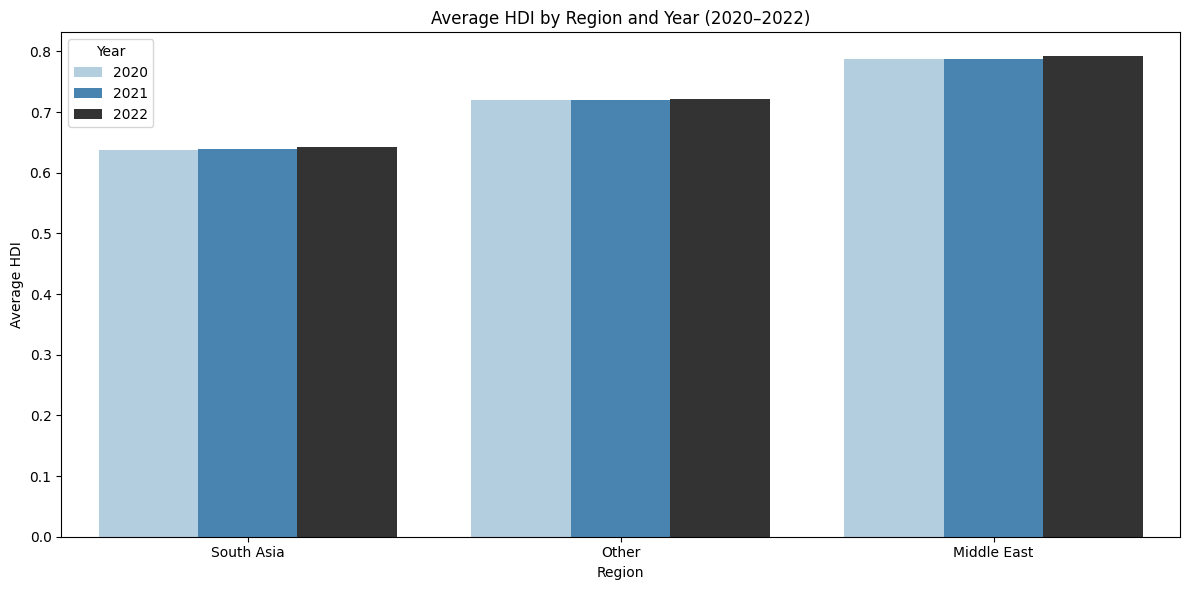

In [86]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=hdi_1b,
    x='region',
    y='hdi',
    hue='year',
    palette='Blues_d',
    errorbar=None
)

plt.xlabel("Region")
plt.ylabel("Average HDI")
plt.title("Average HDI by Region and Year (2020–2022)")
plt.legend(title='Year')
plt.tight_layout()
plt.show()

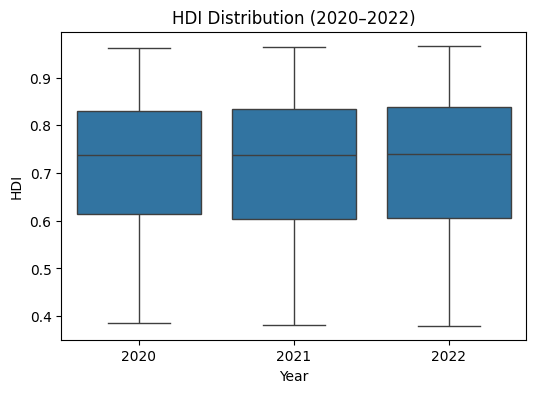

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=hdi_1b, x='year', y='hdi')
plt.xlabel("Year")
plt.ylabel("HDI")
plt.title("HDI Distribution (2020–2022)")
plt.show()


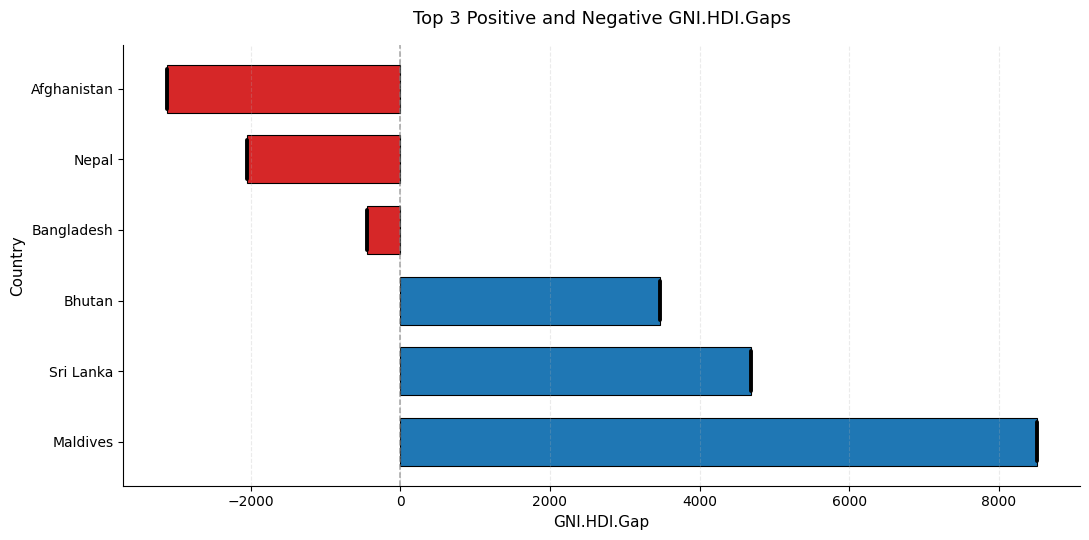

In [87]:
positive = sa_avg[sa_avg['GNI_HDI_Gap'] > 0].nlargest(3, 'GNI_HDI_Gap')
negative  = sa_avg[sa_avg['GNI_HDI_Gap'] < 0].nsmallest(3, 'GNI_HDI_Gap')
combined = pd.concat([positive, negative]).sort_values('GNI_HDI_Gap', ascending=False)

colors = ['#1f77b4' if x >= 0 else '#d62728' for x in combined['GNI_HDI_Gap']]
plt.figure(figsize=(11, 5.5))
bars = plt.barh(
    combined['country'],
    combined['GNI_HDI_Gap'],
    color=colors,
    height=0.68,
    edgecolor='black',
    linewidth=0.8
)
for bar in bars:
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.plot([x, x], [y - 0.28, y + 0.28], color='black', lw=2.8, solid_capstyle='round')

plt.axvline(0, color='gray', linestyle='--', linewidth=1.1, alpha=0.7)

plt.title("Top 3 Positive and Negative GNI.HDI.Gaps", fontsize=13, pad=15)
plt.xlabel("GNI.HDI.Gap", fontsize=11)
plt.ylabel("Country", fontsize=11)

plt.grid(axis='x', alpha=0.25, linestyle='--')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


plt.subplots_adjust(left=0.24)

plt.tight_layout()
plt.show()

In [88]:
hdi_1b['year'] = pd.to_numeric(hdi_1b['year'], errors='coerce')


In [89]:
hdi_change = hdi_1b.pivot_table(
    index='country',
    columns='year',
    values='hdi',
    aggfunc='mean'
)


In [90]:
hdi_change.columns = hdi_change.columns.astype(int)


In [91]:
first_year = hdi_change.columns.min()
last_year = hdi_change.columns.max()
hdi_change['HDI_Change'] = hdi_change[last_year] - hdi_change[first_year]


In [92]:
hdi_change.sort_values('HDI_Change', ascending=False).head()


year,2020,2021,2022,HDI_Change
country,,,,
Andorra,0.843,0.855,0.884,0.041
Azerbaijan,0.722,0.738,0.760,0.038
Ecuador,0.734,0.746,0.765,0.031
Maldives,0.737,0.753,0.762,0.025
Mexico,0.757,0.757,0.781,0.024


In [ ]:
hdi_change[hdi_change['HDI_Change'] < 0]


year,2020,2021,2022,HDI_Change
country,,,,
Afghanistan,0.488,0.473,0.462,-0.026
Angola,0.594,0.590,0.591,-0.003
Australia,0.948,0.949,0.946,-0.002
Belize,0.705,0.698,0.700,-0.005
Brunei Darussalam,0.827,0.824,0.823,-0.004
Bulgaria,0.802,0.796,0.799,-0.003
Burkina Faso,0.446,0.445,0.438,-0.008
Central African Republic,0.389,0.387,0.387,-0.002
Chad,0.396,0.393,0.394,-0.002


In [93]:
south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]
south_asia_df = df[df['country'].isin(south_asia_countries)].copy()

numeric_cols = ['hdi', 'life_expectancy', 'gross_inc_percap', 'gender_development']
for col in numeric_cols:
    if col in south_asia_df.columns:
        south_asia_df[col] = pd.to_numeric(south_asia_df[col], errors='coerce')

south_asia_df.to_csv("HDI_SouthAsia.csv", index=False)

print("South Asia subset created and saved as: HDI_SouthAsia.csv")
print("Number of rows:", len(south_asia_df))
print("Unique countries:", sorted(south_asia_df['country'].unique()))

South Asia subset created and saved as: HDI_SouthAsia.csv
Number of rows: 264
Unique countries: ['Afghanistan', 'Bangladesh', 'Bhutan', 'India', 'Maldives', 'Nepal', 'Pakistan', 'Sri Lanka']


HDI vs Composite Score Ranking Comparison:
             HDI_Rank  Composite_Rank  Avg_HDI  Avg_Composite
country                                                      
Afghanistan         8               8    0.401            555
Bangladesh          5               6    0.531           1043
Bhutan              3               3    0.635           1878
India               4               5    0.541           1151
Maldives            2               1    0.682           4154
Nepal               6               7    0.504            779
Pakistan            7               4    0.473           1184
Sri Lanka           1               2    0.716           2503


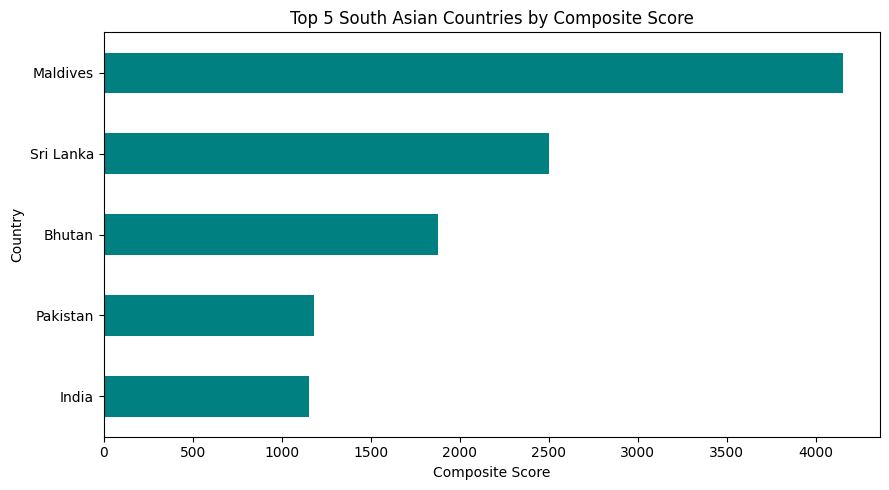

In [94]:
south_asia_df['Composite_Score'] = (
    0.30 * south_asia_df['life_expectancy'].fillna(0) +
    0.30 * south_asia_df['gross_inc_percap'].fillna(0)
)
composite_rank = south_asia_df.groupby('country')['Composite_Score'].mean().sort_values(ascending=False)

hdi_rank = south_asia_df.groupby('country')['hdi'].mean().sort_values(ascending=False)


comparison = pd.DataFrame({
    'HDI_Rank': hdi_rank.rank(ascending=False).astype(int),
    'Composite_Rank': composite_rank.rank(ascending=False).astype(int),
    'Avg_HDI': hdi_rank.round(3),
    'Avg_Composite': composite_rank.round(0).astype(int)
})

print("HDI vs Composite Score Ranking Comparison:")
print(comparison)
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
composite_rank.head(5).sort_values().plot(kind='barh', color='teal')
plt.title("Top 5 South Asian Countries by Composite Score")
plt.xlabel("Composite Score")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

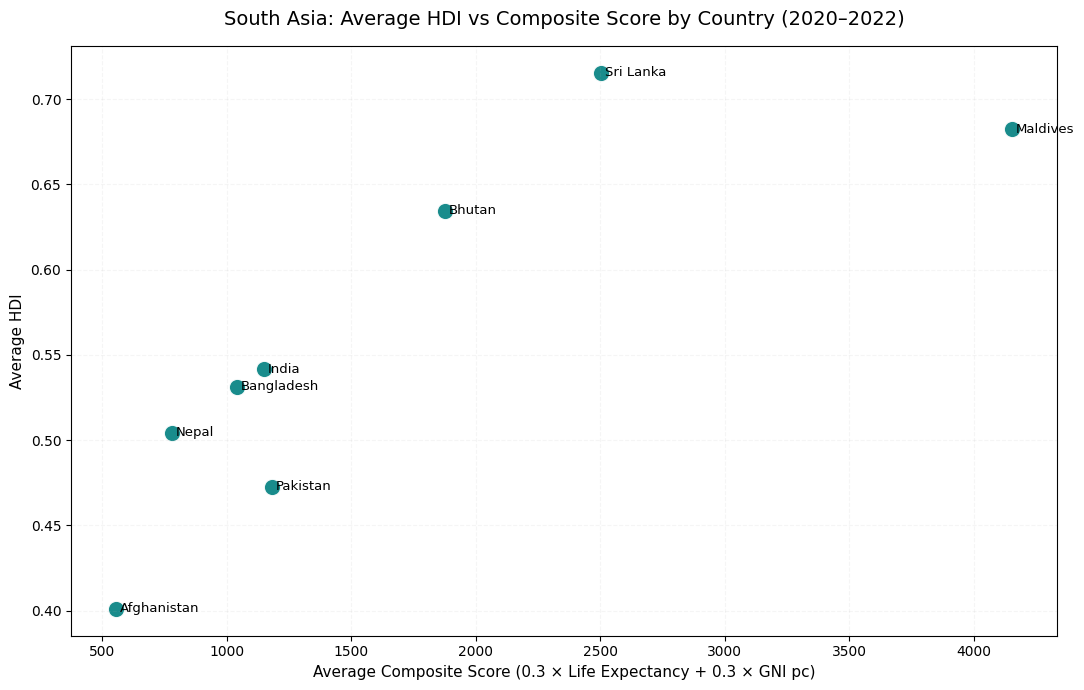

In [95]:
if 'Composite_Score' not in south_asia_df.columns:
    south_asia_df['Composite_Score'] = (
        0.30 * south_asia_df['life_expectancy'].fillna(south_asia_df['life_expectancy'].mean()) +
        0.30 * south_asia_df['gross_inc_percap'].fillna(south_asia_df['gross_inc_percap'].mean())
    )
country_avg = south_asia_df.groupby('country').agg({
    'hdi': 'mean',
    'Composite_Score': 'mean'
}).rename(columns={'hdi': 'Avg_HDI', 'Composite_Score': 'Avg_Composite'})
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=country_avg,
    x='Avg_Composite',
    y='Avg_HDI',
    s=140,
    color='teal',
    alpha=0.9,
    edgecolor='white'
)
for country, row in country_avg.iterrows():
    plt.text(
        row['Avg_Composite'] + 15,
        row['Avg_HDI'],
        country,
        fontsize=9.5,
        fontweight='medium',
        va='center'
    )

plt.title("South Asia: Average HDI vs Composite Score by Country (2020–2022)", fontsize=14, pad=15)
plt.xlabel("Average Composite Score (0.3 × Life Expectancy + 0.3 × GNI pc)", fontsize=11)
plt.ylabel("Average HDI", fontsize=11)
plt.grid(True, alpha=0.12, linestyle='--')
plt.tight_layout()
plt.show()

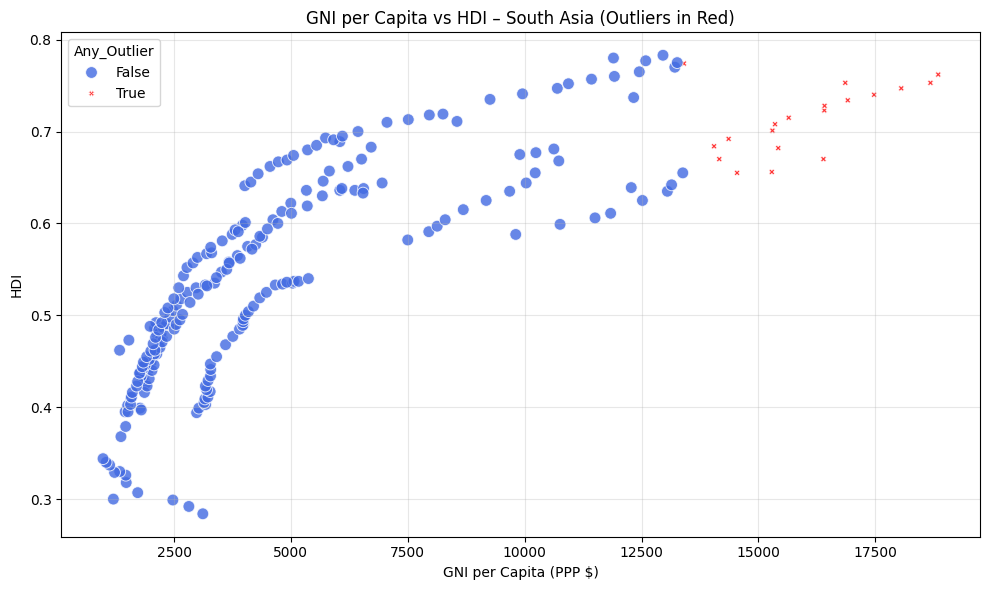

Countries with outliers (HDI or GNI): ['Maldives', 'Sri Lanka']


In [96]:
import seaborn as sns

def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)
south_asia_df['HDI_Outlier'] = detect_outliers(south_asia_df['hdi'])
south_asia_df['GNI_Outlier'] = detect_outliers(south_asia_df['gross_inc_percap'])
south_asia_df['Any_Outlier'] = south_asia_df['HDI_Outlier'] | south_asia_df['GNI_Outlier']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=south_asia_df,
    x='gross_inc_percap',
    y='hdi',
    hue='Any_Outlier',
    style='Any_Outlier',
    size='Any_Outlier',
    palette={False: 'royalblue', True: 'red'},
    alpha=0.8
)
plt.title("GNI per Capita vs HDI – South Asia (Outliers in Red)")
plt.xlabel("GNI per Capita (PPP $)")
plt.ylabel("HDI")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


outliers = south_asia_df[south_asia_df['Any_Outlier']]['country'].unique()
print("Countries with outliers (HDI or GNI):", list(outliers))

In [ ]:
hdi_rank = south_asia_df.groupby('country')['hdi'].mean().sort_values(ascending=False)

comparison_df = pd.DataFrame({
    'HDI_Rank': hdi_rank.rank(ascending=False),
    'Composite_Rank': composite_rank.rank(ascending=False)
})

comparison_df


,HDI_Rank,Composite_Rank
country,,
Afghanistan,8.0,8.0
Bangladesh,5.0,6.0
Bhutan,3.0,3.0
India,4.0,5.0
Maldives,2.0,1.0
Nepal,6.0,7.0
Pakistan,7.0,4.0
Sri Lanka,1.0,2.0


In [97]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)
south_asia_df['HDI_Outlier'] = detect_outliers(south_asia_df['hdi'])
south_asia_df['GNI_Outlier'] = detect_outliers(south_asia_df['gross_inc_percap'])


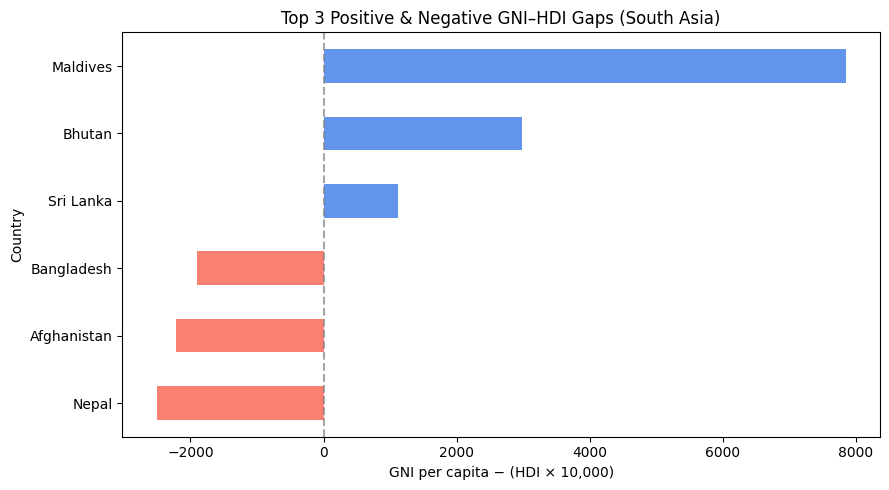

Top positive and negative GNI-HDI gaps:
country
Nepal         -2509.0
Afghanistan   -2216.0
Bangladesh    -1904.0
Sri Lanka      1113.0
Bhutan         2975.0
Maldives       7846.0
Name: GNI_HDI_Gap, dtype: float64


In [98]:
south_asia_df['GNI_HDI_Gap'] = south_asia_df['gross_inc_percap'] - (south_asia_df['hdi'] * 10000)


gap_per_country = south_asia_df.groupby('country')['GNI_HDI_Gap'].mean().sort_values()


top_positive = gap_per_country.tail(3)
top_negative = gap_per_country.head(3)
top_gaps = pd.concat([top_positive, top_negative]).sort_values()


plt.figure(figsize=(9, 5))
colors = ['salmon' if x < 0 else 'cornflowerblue' for x in top_gaps]
top_gaps.plot(kind='barh', color=colors)
plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.title("Top 3 Positive & Negative GNI–HDI Gaps (South Asia)")
plt.xlabel("GNI per capita − (HDI × 10,000)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

print("Top positive and negative GNI-HDI gaps:")
print(top_gaps.round(0))

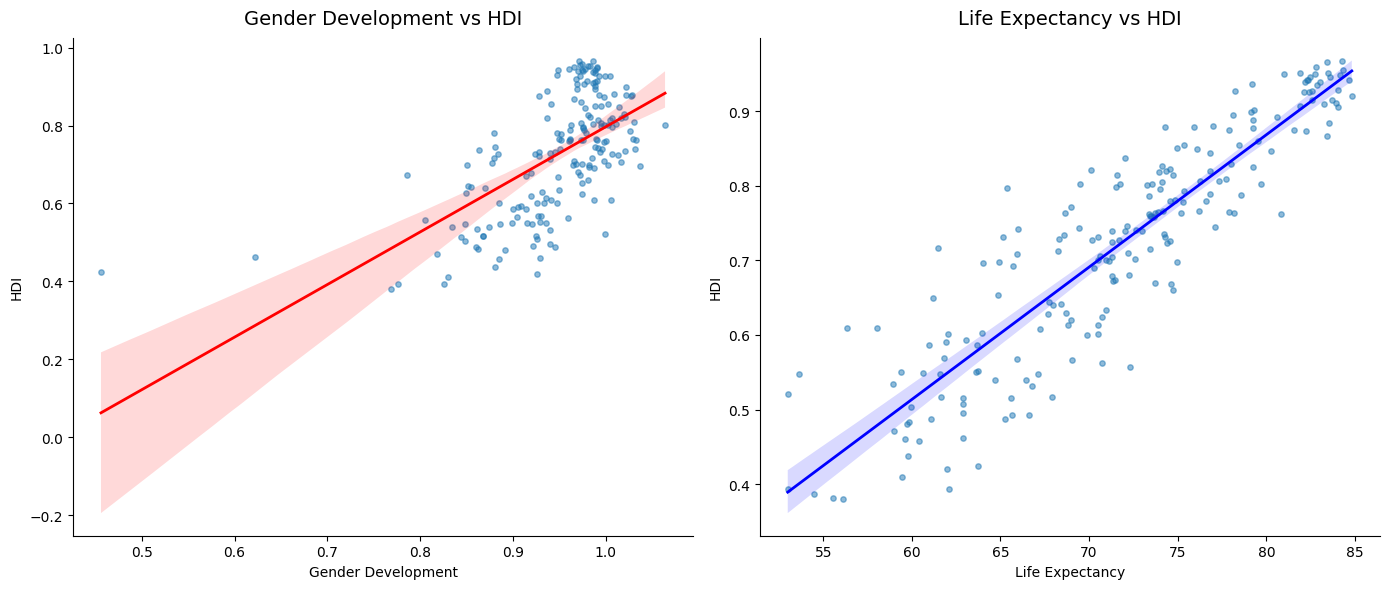

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.regplot(
    data=hdi_2022_df,
    x='gender_development',
    y='hdi',
    ax=axes[0],

    scatter_kws={'alpha': 0.5, 's': 15, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'linewidth': 2}
)
axes[0].set_title("Gender Development vs HDI", fontsize=14, pad=10)
axes[0].set_xlabel("Gender Development")
axes[0].set_ylabel("HDI")

sns.regplot(
    data=hdi_2022_df,
    x='life_expectancy',
    y='hdi',
    ax=axes[1],
    scatter_kws={'alpha': 0.5, 's': 15, 'color': '#1f77b4'},
    line_kws={'color': 'blue', 'linewidth': 2}
)
axes[1].set_title("Life Expectancy vs HDI", fontsize=14, pad=10)
axes[1].set_xlabel("Life Expectancy")
axes[1].set_ylabel("HDI")
sns.despine()
plt.tight_layout()
plt.show()

In [100]:
corr_life = south_asia_df['life_expectancy'].corr(south_asia_df['hdi'])
corr_gender = south_asia_df['gender_development'].corr(south_asia_df['hdi'])

corr_life, corr_gender


(np.float64(0.9587610559043978), np.float64(0.865621005012754))

In [101]:
south_asia_df['GNI_HDI_Gap'] = south_asia_df['gross_inc_percap'] - south_asia_df['hdi']


In [102]:
gap_rank_desc = south_asia_df.sort_values('GNI_HDI_Gap', ascending=False)
gap_rank_asc = south_asia_df.sort_values('GNI_HDI_Gap')

gap_rank_desc[['country','GNI_HDI_Gap']].head(3), gap_rank_asc[['country','GNI_HDI_Gap']].head(3)


(       country  GNI_HDI_Gap
 3530  Maldives  18846.03019
 3527  Maldives  18679.17236
 3526  Maldives  18054.97765,
         country  GNI_HDI_Gap
 11  Afghanistan   980.789554
 10  Afghanistan  1047.002686
 9   Afghanistan  1121.985570)

In [104]:
numeric_cols = ['hdi','life_expectancy','gross_inc_percap','gender_development']
for col in numeric_cols:
    hdi_1b[col] = pd.to_numeric(hdi_1b[col], errors='coerce')
south_asia = [
    "Afghanistan","Bangladesh","Bhutan","India",
    "Maldives","Nepal","Pakistan","Sri Lanka"
]

middle_east = [
    "Bahrain","Iran","Iraq","Israel","Jordan","Kuwait","Lebanon",
    "Oman","Palestine","Qatar","Saudi Arabia","Syria",
    "United Arab Emirates","Yemen"
]

south_asia_df = hdi_1b[hdi_1b['country'].isin(south_asia)].copy()
middle_east_df = hdi_1b[hdi_1b['country'].isin(middle_east)].copy()

south_asia_df.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
middle_east_df.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)

In [ ]:
stats = pd.DataFrame({
    "Region": ["South Asia", "Middle East"],
    "Mean_HDI": [
        south_asia_df['hdi'].mean(),
        middle_east_df['hdi'].mean()
    ],
    "Std_HDI": [
        south_asia_df['hdi'].std(),
        middle_east_df['hdi'].std()
    ]
})

stats


,Region,Mean_HDI,Std_HDI
0,South Asia,0.639583,0.098273
1,Middle East,0.788909,0.141295


In [ ]:
sa_avg = south_asia_df.groupby('country')['hdi'].mean()
me_avg = middle_east_df.groupby('country')['hdi'].mean()

sa_top = sa_avg.sort_values(ascending=False).head(3)
sa_bottom = sa_avg.sort_values().head(3)

me_top = me_avg.sort_values(ascending=False).head(3)
me_bottom = me_avg.sort_values().head(3)


In [105]:
sa_avg = south_asia_df.groupby('country')['hdi'].mean()
me_avg = middle_east_df.groupby('country')['hdi'].mean()


sa_top = sa_avg.sort_values(ascending=False).head(3)
sa_bottom = sa_avg.sort_values(ascending=False).tail(3)


me_top = me_avg.sort_values(ascending=False).head(3)
me_bottom = me_avg.sort_values(ascending=False).tail(3)


print("South Asia - Top 3:\n", sa_top)
print("\nSouth Asia - Bottom 3:\n", sa_bottom)
print("\nMiddle East - Top 3:\n", me_top)
print("\nMiddle East - Bottom 3:\n", me_bottom)

South Asia - Top 3:
 country
Sri Lanka    0.780000
Maldives     0.750667
Bhutan       0.677667
Name: hdi, dtype: float64

South Asia - Bottom 3:
 country
Nepal          0.595000
Pakistan       0.537667
Afghanistan    0.474333
Name: hdi, dtype: float64

Middle East - Top 3:
 country
United Arab Emirates    0.932667
Israel                  0.910667
Bahrain                 0.885333
Name: hdi, dtype: float64

Middle East - Bottom 3:
 country
Lebanon    0.730000
Iraq       0.667000
Yemen      0.426333
Name: hdi, dtype: float64


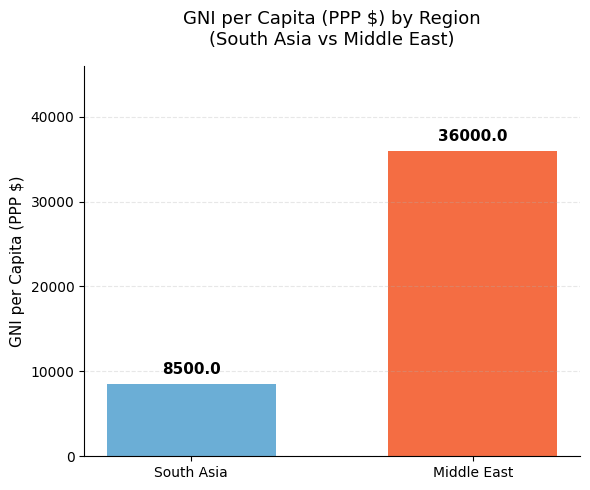

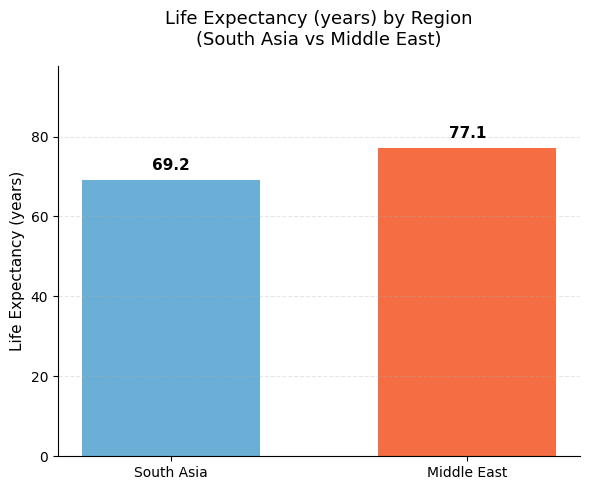

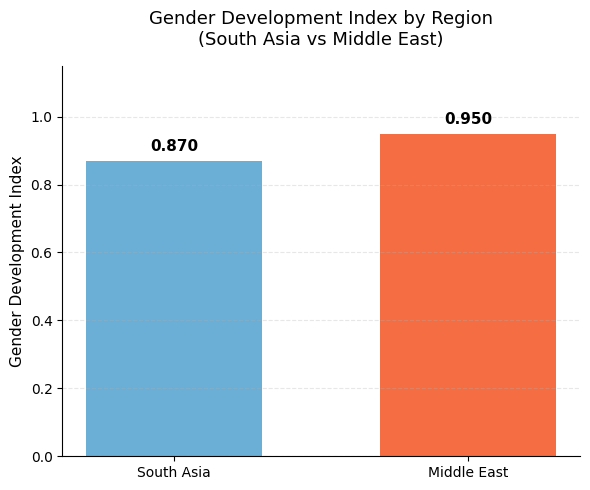

In [106]:
regions = ['South Asia', 'Middle East']

gni_values = [8500, 36000]
life_exp_values = [69.2, 77.1]
gdi_values = [0.87, 0.95]

metrics = [
    ("GNI per Capita (PPP $)", gni_values, 40000),
    ("Life Expectancy (years)", life_exp_values, 85),
    ("Gender Development Index", gdi_values, 1.0)
]

for title, values, max_y in metrics:
    plt.figure(figsize=(6, 5))

    colors = ['#6baed6', '#f46d43']

    bars = plt.bar(regions, values, color=colors, width=0.6)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02*max_y,
                 f'{yval:.1f}' if yval > 1 else f'{yval:.3f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.ylim(0, max_y * 1.15)
    plt.title(f"{title} by Region\n(South Asia vs Middle East)", fontsize=13, pad=15)
    plt.ylabel(title, fontsize=11)
    plt.grid(axis='y', alpha=0.3, linestyle='--')

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

In [107]:
disparity = pd.DataFrame({
    "Region": ["South Asia","Middle East"],
    "HDI_Range": [
        south_asia_df['hdi'].max() - south_asia_df['hdi'].min(),
        middle_east_df['hdi'].max() - middle_east_df['hdi'].min()
    ],
    "HDI_CV": [
        south_asia_df['hdi'].std() / south_asia_df['hdi'].mean(),
        middle_east_df['hdi'].std() / middle_east_df['hdi'].mean()
    ]
})

disparity


,Region,HDI_Range,HDI_CV
0,South Asia,0.321,0.153652
1,Middle East,0.513,0.179101


In [108]:
corr_df = pd.DataFrame({
    "Region": ["South Asia","Middle East"],
    "HDI vs Gender Dev": [
        south_asia_df['hdi'].corr(south_asia_df['gender_development']),
        middle_east_df['hdi'].corr(middle_east_df['gender_development'])
    ],
    "HDI vs Life Expectancy": [
        south_asia_df['hdi'].corr(south_asia_df['life_expectancy']),
        middle_east_df['hdi'].corr(middle_east_df['life_expectancy'])
    ]
})

corr_df


,Region,HDI vs Gender Dev,HDI vs Life Expectancy
0,South Asia,0.874218,0.938764
1,Middle East,0.935670,0.933123


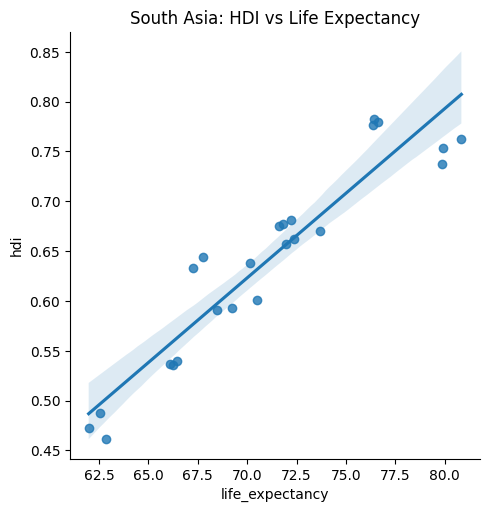

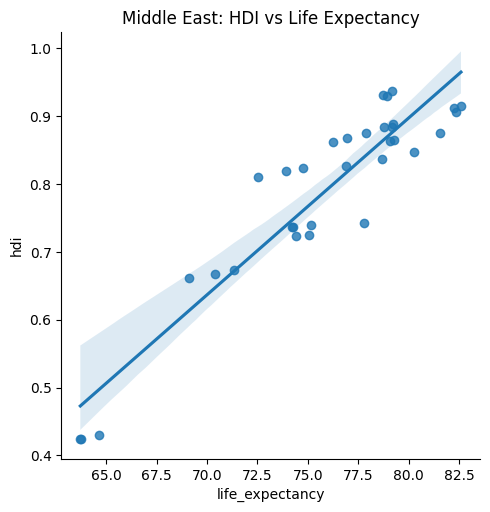

In [109]:
sns.lmplot(data=south_asia_df, x='life_expectancy', y='hdi')
plt.title("South Asia: HDI vs Life Expectancy")
plt.show()

sns.lmplot(data=middle_east_df, x='life_expectancy', y='hdi')
plt.title("Middle East: HDI vs Life Expectancy")
plt.show()


In [ ]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)

south_asia_df['Outlier'] = (
    detect_outliers(south_asia_df['hdi']) |
    detect_outliers(south_asia_df['gross_inc_percap'])
)

middle_east_df['Outlier'] = (
    detect_outliers(middle_east_df['hdi']) |
    detect_outliers(middle_east_df['gross_inc_percap'])
)


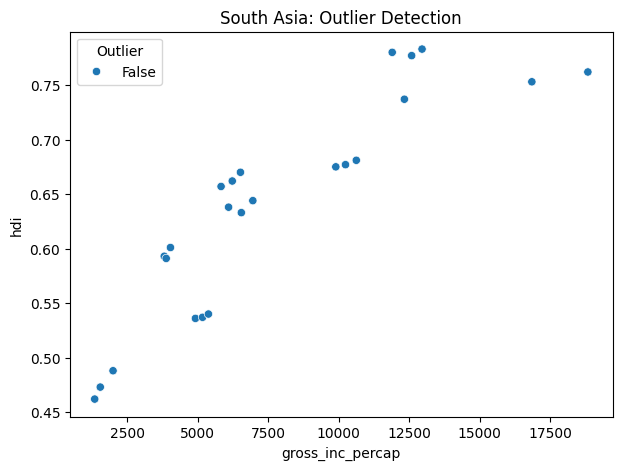

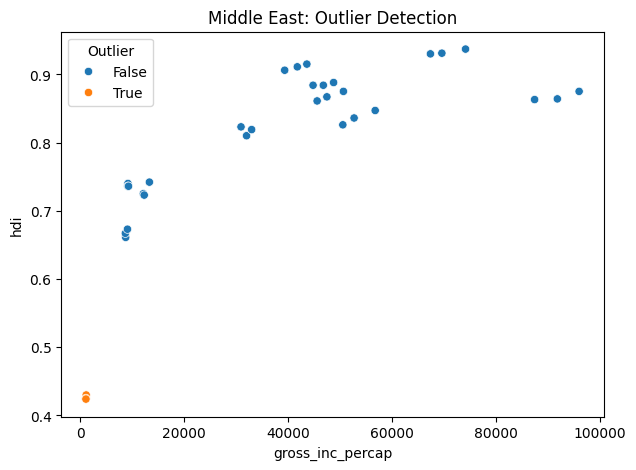

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=south_asia_df,
    x='gross_inc_percap', y='hdi',
    hue='Outlier'
)
plt.title("South Asia: Outlier Detection")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=middle_east_df,
    x='gross_inc_percap', y='hdi',
    hue='Outlier'
)
plt.title("Middle East: Outlier Detection")
plt.show()
